In [1]:
# Preparacion
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
# Carga de la tabla drivers
drivers = pd.read_csv(
    "../files/input/drivers.csv",
    sep=",",
    thousands=None,
    decimal=".",
)
drivers.head()

,driverId,name,ssn,location,certified,wage-plan
0,10,George Vetticaden,621011971,244-4532 Nulla Rd.,N,miles
1,11,Jamie Engesser,262112338,366-4125 Ac Street,N,miles
2,12,Paul Coddin,198041975,Ap #622-957 Risus. Street,Y,hours
3,13,Joe Niemiec,139907145,2071 Hendrerit. Ave,Y,hours
4,14,Adis Cesir,820812209,Ap #810-1228 In St.,Y,hours


In [3]:
# Carga de la tabla timesheet
timesheet = pd.read_csv(
    "../files/input/timesheet.csv",
    sep=",",
    thousands=None,
    decimal=".",
)
timesheet.head()

,driverId,week,hours-logged,miles-logged
0,10,1,70,3300
1,10,2,70,3300
2,10,3,60,2800
3,10,4,70,3100
4,10,5,70,3200


In [4]:
# Media de la cantidad de horas y millas de cada conductor por año
mean_timesheet = timesheet.groupby("driverId").mean()
mean_timesheet.head()


,week,hours-logged,miles-logged
driverId,,,
10,26.5,62.153846,2829.807692
11,26.5,70.038462,3448.076923
12,26.5,50.750000,2614.653846
13,26.5,52.442308,2579.346154
14,26.5,53.480769,2627.384615


In [5]:
# Eliminación de la columna 'week'
mean_timesheet.pop("week")
mean_timesheet.head()

,hours-logged,miles-logged
driverId,,
10,62.153846,2829.807692
11,70.038462,3448.076923
12,50.750000,2614.653846
13,52.442308,2579.346154
14,53.480769,2627.384615


In [8]:
# Registros con valores por debajo de la media del grupo
mean_hours_logged_by_driver = timesheet.groupby("driverId")["hours-logged"].transform(
    "mean"
)
mean_hours_logged_by_driver.head()

0    62.153846
1    62.153846
2    62.153846
3    62.153846
4    62.153846
Name: hours-logged, dtype: float64

In [9]:
# Registros con valores por debajo de la media del grupo
mean_hours_logged_by_driver = timesheet.groupby("driverId")["hours-logged"].transform(
    "mean"
)
mean_hours_logged_by_driver.tail(20)

1748    52.884615
1749    52.884615
1750    52.884615
1751    52.884615
1752    52.884615
1753    52.884615
1754    52.884615
1755    52.884615
1756    52.884615
1757    52.884615
1758    52.884615
1759    52.884615
1760    52.884615
1761    52.884615
1762    52.884615
1763    52.884615
1764    52.884615
1765    52.884615
1766    52.884615
1767    52.884615
Name: hours-logged, dtype: float64

In [10]:
timesheet_with_means = timesheet.copy()
timesheet_with_means["mean_hours-logged"] = mean_hours_logged_by_driver
timesheet_with_means.head()

,driverId,week,hours-logged,miles-logged,mean_hours-logged
0,10,1,70,3300,62.153846
1,10,2,70,3300,62.153846
2,10,3,60,2800,62.153846
3,10,4,70,3100,62.153846
4,10,5,70,3200,62.153846


In [11]:
timesheet_below = timesheet_with_means[
    timesheet_with_means["hours-logged"] < timesheet_with_means["mean_hours-logged"]
]
display(timesheet_below.head(), timesheet_below.tail())

,driverId,week,hours-logged,miles-logged,mean_hours-logged
2,10,3,60,2800,62.153846
9,10,10,50,2500,62.153846
19,10,20,30,1200,62.153846
20,10,21,50,2500,62.153846
25,10,26,60,2600,62.153846


,driverId,week,hours-logged,miles-logged,mean_hours-logged
1756,43,41,51,2701,52.884615
1760,43,45,46,2671,52.884615
1762,43,47,50,2572,52.884615
1763,43,48,52,2517,52.884615
1767,43,52,48,2764,52.884615


In [12]:
# Cómputo de la cantidad de horas y millas de cada conductor por año
sum_timesheet = timesheet.groupby("driverId").sum()
sum_timesheet.head(10)


,week,hours-logged,miles-logged
driverId,,,
10,1378,3232,147150
11,1378,3642,179300
12,1378,2639,135962
13,1378,2727,134126
14,1378,2781,136624
15,1378,2734,138750
16,1378,2746,137205
17,1378,2701,135992
18,1378,2654,137834


In [13]:
sum_timesheet = sum_timesheet[["hours-logged", "miles-logged"]]
sum_timesheet.head()

,hours-logged,miles-logged
driverId,,
10,3232,147150
11,3642,179300
12,2639,135962
13,2727,134126
14,2781,136624


In [14]:
timesheet.groupby("driverId")["hours-logged"].agg(["min", "max"])

,min,max
driverId,,
10,0,76
11,0,92
12,0,60
13,10,60
14,45,60
15,45,60
16,45,60
17,20,60
18,45,60


In [15]:
# Unión de las tablas usando join
summary = pd.merge(
    sum_timesheet,
    drivers[["driverId", "name"]],
    on="driverId",
)
summary

,driverId,hours-logged,miles-logged,name
0,10,3232,147150,George Vetticaden
1,11,3642,179300,Jamie Engesser
2,12,2639,135962,Paul Coddin
3,13,2727,134126,Joe Niemiec
4,14,2781,136624,Adis Cesir
5,15,2734,138750,Rohit Bakshi
6,16,2746,137205,Tom McCuch
7,17,2701,135992,Eric Mizell
8,18,2654,137834,Grant Liu
9,19,2738,137968,Ajay Singh


In [16]:
# Almacenamiento de los resultados
import os

if not os.path.exists("../files/output"):
    os.makedirs("../files/output")

summary.to_csv(
    "../files/output/summary.csv",
    sep=",",
    header=True,
    index=False,
)


In [17]:
# Ordenamiento por la cantidad de millas registradas
top10 = summary.sort_values(by="miles-logged", ascending=False).head(10)
top10

,driverId,hours-logged,miles-logged,name
1,11,3642,179300,Jamie Engesser
0,10,3232,147150,George Vetticaden
23,33,2759,139285,Sridhara Sabbella
15,25,2723,139180,Jean-Philippe Playe
29,39,2745,138788,David Kaiser
5,15,2734,138750,Rohit Bakshi
25,35,2728,138727,Emil Siemes
11,21,2751,138719,Jeff Markham
31,41,2723,138407,Greg Phillips
19,29,2760,138255,Teddy Choi


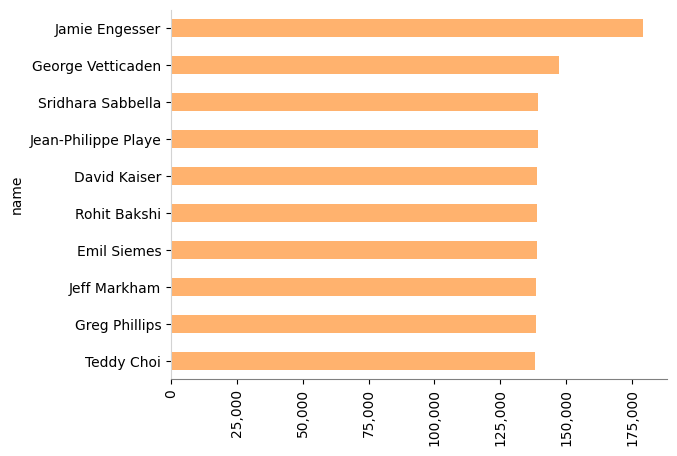

In [18]:
# Creación de un gráfico de barras horizontales
# La columna 'name' pasa a ser el nombre de las filas
top10 = top10.set_index("name")

# Paleta de colores:
#   tab:blue     tab:red       tab:pink
#   tab:orange   tab:purple    tab:gray
#   tab:green    tab:brown     tab:olive
#   tab:cyan
top10["miles-logged"].plot.barh(color="tab:orange", alpha=0.6)

plt.gca().invert_yaxis()

plt.gca().get_xaxis().set_major_formatter(
    matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ","))
)

plt.xticks(rotation=90)

plt.gca().spines["left"].set_color("lightgray")
plt.gca().spines["bottom"].set_color("gray")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

if not os.path.exists("../files/plots"):
    os.makedirs("../files/plots")

plt.savefig("../files/plots/top10_drivers.png", bbox_inches="tight")